In [1]:
!pip install diffusers transformers accelerate

  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached PyYAML-6.0.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.1 kB)
  Using cached tokenizers-0.21.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.4.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached MarkupSafe-3.0.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 74.8 MB/s eta 0:00:00a 0:00:01
Using cached PyYAML-6.0.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (751 kB)
Using cached tokenizers-0

In [1]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

/mnt/nvme_disk2/User_data/ss57076k/pyarmor_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id1 = "dreamlike-art/dreamlike-diffusion-1.0"
model_id2 = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionPipeline.from_pretrained(model_id1, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to("cuda:3")

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 11.16it/s]


In [3]:
prompt = """A high-quality image of a delicious dish
"""

In [4]:
image = pipe(prompt).images[0]

100%|██████████| 50/50 [00:02<00:00, 22.82it/s]


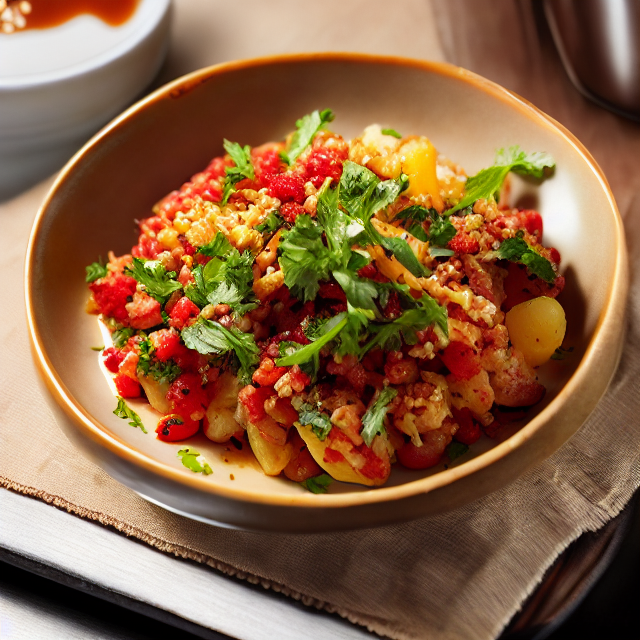

In [5]:
image

[PROMPT]:  dreamlikeart, a grungy woman with rainbow hair, travelling between dimensions, dynamic pose, happy, soft eyes and narrow chin,
extreme bokeh, dainty figure, long hair straight down, torn kawaii shirt and baggy jeans



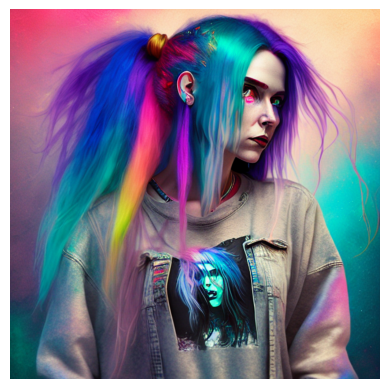

In [9]:
print("[PROMPT]: ",prompt)
plt.imshow(image);
plt.axis('off');

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', facebook ads manager , mailchimp for emails , and google analytics for tracking performance . apply your skills by creating a blog or website , running test ad campaigns , and managing social media accounts . learn to analyze data using tools like google analytics and perform a / b testing to improve results . earning certifications such as google ads , google analytics , and hubspot content marketing can help validate your skills . stay updated by following industry blogs , joining online communities , and attending webinars . finally , consider specializing in one area like seo , social media marketing , or email marketing based on your interests and strengths .']
100%|██████████| 50/50 [00:01<00:00, 32.29it/s]


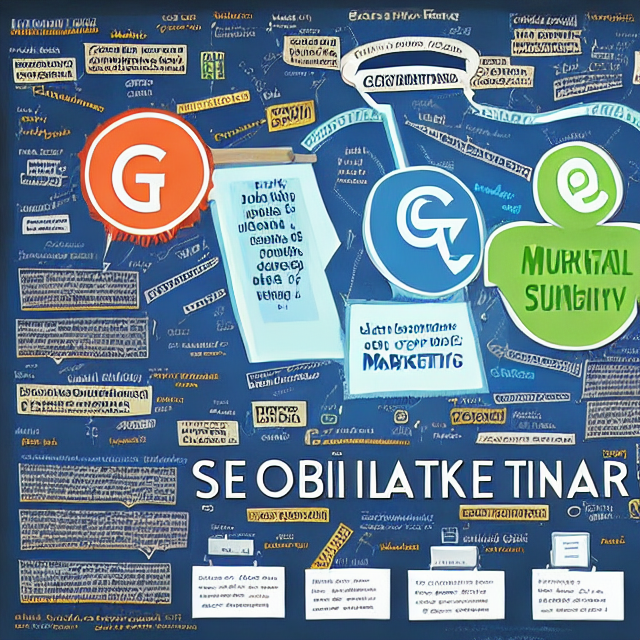

In [18]:
prompt_dig='Give me the plot/diagram to explain this, so that i can paste in ppt: To learn digital marketing, start by understanding the basics such as SEO, SEM, content marketing, social media, email marketing, and analytics. Free resources like Google Digital Garage and HubSpot Academy are great places to begin. Next, familiarize yourself with popular tools like Google Ads, Facebook Ads Manager, Mailchimp for emails, and Google Analytics for tracking performance. Apply your skills by creating a blog or website, running test ad campaigns, and managing social media accounts. Learn to analyze data using tools like Google Analytics and perform A/B testing to improve results. Earning certifications such as Google Ads, Google Analytics, and HubSpot Content Marketing can help validate your skills. Stay updated by following industry blogs, joining online communities, and attending webinars. Finally, consider specializing in one area like SEO, social media marketing, or email marketing based on your interests and strengths.'
image = pipe(prompt_dig).images[0]
image

In [21]:
!pip install graphviz


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 KB 360.0 kB/s eta 0:00:00a 0:00:01


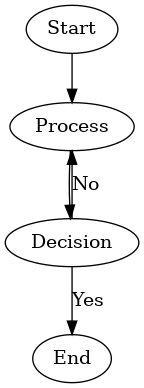

In [23]:
from graphviz import Digraph

# Create a directed graph
dot = Digraph(comment='Simple Flowchart')

# Add nodes
dot.node('A', 'Start')
dot.node('B', 'Process')
dot.node('C', 'Decision')
dot.node('D', 'End')

# Add edges
dot.edges(['AB', 'BC'])
dot.edge('C', 'D', label='Yes')
dot.edge('C', 'B', label='No')

# Render to file (creates flowchart.png)
dot.render(directory='output', filename='flowchart', format='png', cleanup=True)

# Optional: view the DOT source
from PIL import Image
Image.open('flowchart.png').show()


Styled flowchart saved as styled_flowchart.png


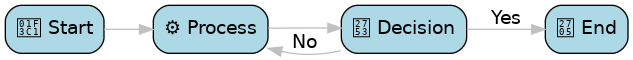

In [25]:
from graphviz import Digraph

dot = Digraph(comment='Styled Flowchart')

# Set global graph attributes
dot.attr(bgcolor='white', rankdir='LR', fontsize='20')

# Set node style
dot.attr('node', shape='box', style='filled,rounded', fillcolor='lightblue', fontname='Helvetica', fontcolor='black')

# Add nodes
dot.node('A', '🏁 Start')
dot.node('B', '⚙️ Process')
dot.node('C', '❓ Decision')
dot.node('D', '✅ End')

# Set edge style
dot.attr('edge', fontname='Helvetica', fontsize='14', color='gray')

# Add edges
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D', label='Yes')
dot.edge('C', 'B', label='No')

# Render to PNG
dot.render(filename='styled_flowchart', format='png', cleanup=True)

print("Styled flowchart saved as styled_flowchart.png")

from PIL import Image
Image.open('styled_flowchart.png').show()


In [30]:
# !curl -o- https://raw.githubusercontent.com/nvm-sh/nvm/v0.39.5/install.sh | bash

In [1]:
from langchain_core.messages import HumanMessage
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv  # Import load_dotenv


load_dotenv()

config = {"configurable": {"thread_id": "abc123"}}
model = init_chat_model("llama-3.1-8b-instant", model_provider="groq",max_tokens=2000)

prompt='''You are a diagram generator. Convert the following description into a Mermaid flowchart using markdown syntax. 
Keep it readable, structured, and use emojis if appropriate.
Output only the Mermaid code: User visits the login page, enters credentials, submits the form, gets authenticated, and lands on the dashboard.'''

response = model.invoke([HumanMessage(content=prompt)],config=config)

print(response.content)
# Save to file
with open("diagram.mmd", "w") as f:
    f.write(response.content)


```mermaid
graph LR
    User{Visits Login Page} -->|Submits Form|> Submit[Submit Credentials]
    Submit -->|Successful Authentication|> Authenticated[Gets Authenticated]
    Authenticated -->|Redirected|> Dashboard[Lands on Dashboard]
```


In [2]:
!mmdc -i diagram.mmd -o diagram.png --theme forest --backgroundColor transparent


/bin/bash: line 1: mmdc: command not found


In [ ]:

def paragraph_to_mermaid(prompt):
    system_prompt = """
You are a diagram generator. Convert the following description into a Mermaid flowchart using markdown syntax. 
Keep it readable, structured, and use emojis if appropriate.
Output only the Mermaid code.
    """

    response = openai.ChatCompletion.create(
        model="gpt-4",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
    )
    
    return response['choices'][0]['message']['content']

# Sample input
description = "User visits the login page, enters credentials, submits the form, gets authenticated, and lands on the dashboard."

# Convert to Mermaid
mermaid_code = paragraph_to_mermaid(description)

# Save to file
with open("diagram.mmd", "w") as f:
    f.write(mermaid_code)

print("Mermaid diagram written to diagram.mmd")


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['test ad campaigns manage social media pages send test email campaigns 📊 4 . analyze and improve use google analytics track conversions & user behavior a / b test your content 📜 5 . get certified boost your credibility with : google ads & analytics certs hubspot , meta blueprint 🔁 6 . stay updated follow blogs : moz , neil patel join communities : reddit , linkedin attend webinars / events 🎯 7 . choose a specialization focus on what you enjoy most : seo , ppc , social media , email , etc . give a simple flow chart of these steps']
100%|██████████| 50/50 [00:01<00:00, 34.78it/s]


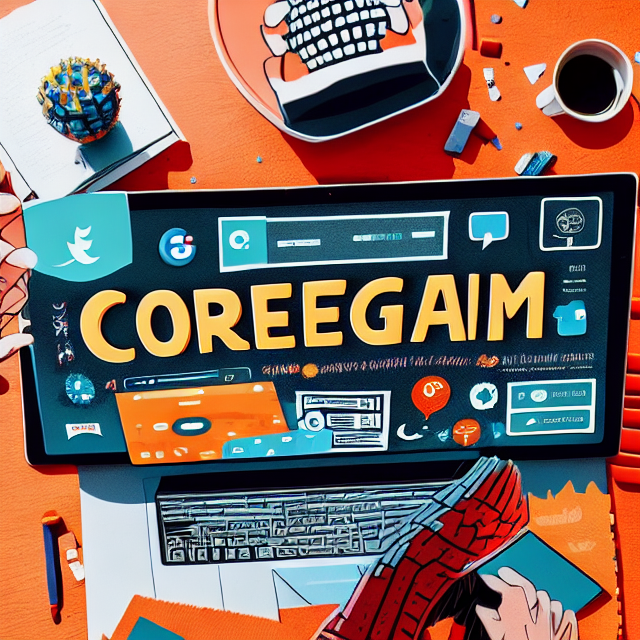

In [20]:
prompt_dig2='''🚀 1. Learn the Basics
Understand core areas:

SEO, SEM, Content Marketing

Social Media, Email, Analytics

📚 Try: Google Digital Garage, HubSpot Academy

🧰 2. Learn Tools
Familiar tools:

SEO: Google Search Console, Ahrefs

Ads: Google Ads, Facebook Ads

Email: Mailchimp

Analytics: Google Analytics

🧪 3. Practice
Create a blog/website

Run test ad campaigns

Manage social media pages

Send test email campaigns

📊 4. Analyze and Improve
Use Google Analytics

Track conversions & user behavior

A/B test your content

📜 5. Get Certified
Boost your credibility with:

Google Ads & Analytics Certs

HubSpot, Meta Blueprint

🔁 6. Stay Updated
Follow blogs: Moz, Neil Patel

Join communities: Reddit, LinkedIn

Attend webinars/events

🎯 7. Choose a Specialization
Focus on what you enjoy most:

SEO, PPC, Social Media, Email, etc. give a simple flow chart of these steps'''
image = pipe(prompt_dig2).images[0]
image

In [10]:
def generate_image(pipe, prompt, params):
  img = pipe(prompt, **params).images

  num_images = len(img)
  if num_images>1:
    fig, ax = plt.subplots(nrows=1, ncols=num_images)
    for i in range(num_images):
      ax[i].imshow(img[i]);
      ax[i].axis('off');

  else:
    fig = plt.figure()
    plt.imshow(img[0]);
    plt.axis('off');
  plt.tight_layout()

100%|██████████| 50/50 [00:01<00:00, 28.73it/s]


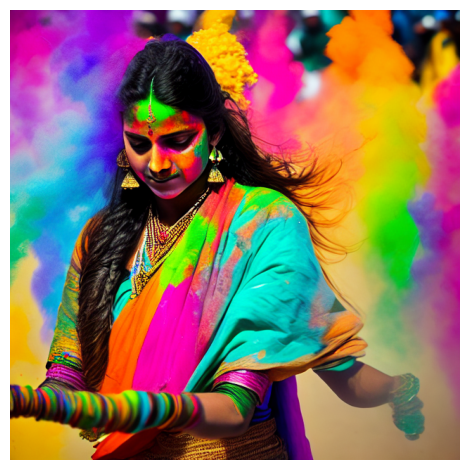

In [11]:
prompt = "dreamlike, beautiful girl playing the festival of colors, draped in traditional Indian attire, throwing colors"

params = {}
generate_image(pipe, prompt, params)

100%|██████████| 100/100 [00:02<00:00, 41.99it/s]


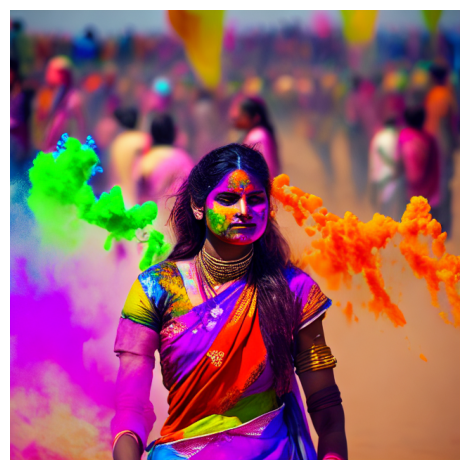

In [12]:
#num inference steps
params = {'num_inference_steps': 100}

generate_image(pipe, prompt, params)

100%|██████████| 100/100 [00:03<00:00, 29.48it/s]


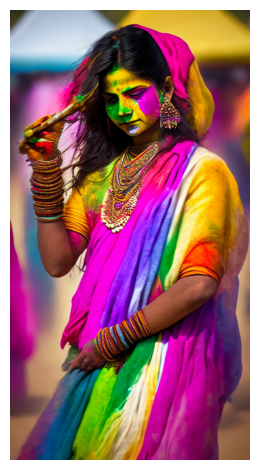

In [13]:
#height width
params = {'num_inference_steps': 100, 'width': 512, 'height': int(1.5*640)}

generate_image(pipe, prompt, params)

100%|██████████| 100/100 [00:03<00:00, 28.06it/s]


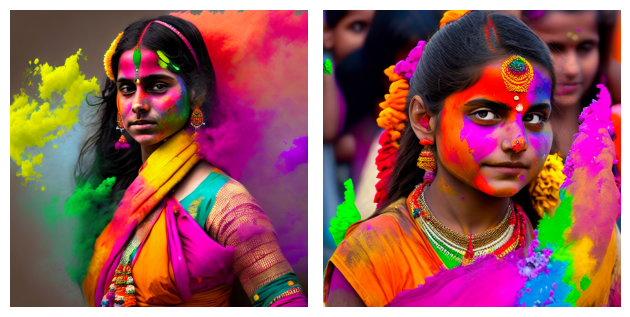

In [14]:
#num_images_per_prompt
params = {'num_inference_steps': 100, 'num_images_per_prompt': 2}

generate_image(pipe, prompt, params)

100%|██████████| 100/100 [00:03<00:00, 28.32it/s]


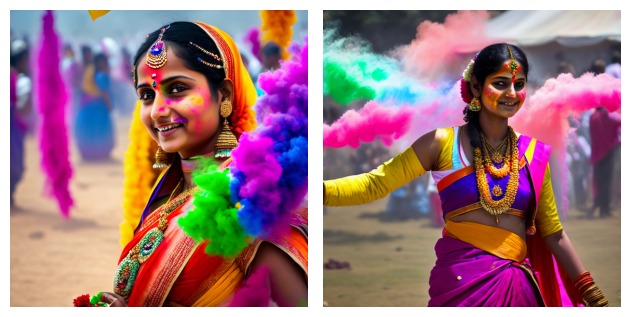

In [15]:
# negative_prompt
params = {'num_inference_steps': 100, 'num_images_per_prompt': 2, 'negative_prompt': 'ugly, distorted, low quality'}

generate_image(pipe, prompt, params)

In [1]:
!pip install -U diffusers


In [8]:
import getpass
import os
# from tools.Rag_tool import RAGTool
# from tools.med_report_analyser import OCRTool
# from tools.med_report_analyser_copy import OCRTool
# from tools.websearch import WebSearchTool
from langgraph.prebuilt import create_react_agent
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv  # Import load_dotenv

memory = MemorySaver()
load_dotenv()
# retrieval_tool = RAGTool(index_path="/home/shivas/Medchat/faiss_index")

# websearch = WebSearchTool()
# tools = [websearch]

if not os.environ.get("GROQ_API_KEY"):
  os.environ["GROQ_API_KEY"] = getpass.getpass("Enter API key for Groq: ")


model = init_chat_model("llama-3.3-70b-versatile", model_provider="groq",max_tokens=4000)
config = {"configurable": {"thread_id": "abc123"}}
# agent_executor=create_react_agent(model,tools,checkpointer=memory)


In [9]:
from langchain_core.messages import HumanMessage

response = model.invoke([HumanMessage(content="i want to do a marketing campiagn for by food delivery comanpy write linkdin post for me")],config=config)

response.content
type(response.content)
print(response.content)

Here's a sample LinkedIn post for your food delivery company's marketing campaign:

**Post Title:** Delivering More Than Just Food: Join the Movement!

**Post:**

Are you tired of the same old lunch routine? Look no further! At [Your Company Name], we're revolutionizing the way you experience food delivery. Our mission is to bring people together through the power of delicious, convenient, and affordable meals.

With a wide range of cuisines to choose from, our platform connects you with the best local restaurants and food establishments. Whether you're a busy professional, a foodie, or just someone who loves trying new things, we've got you covered.

**What sets us apart:**

* **Quality and variety**: Our partner restaurants are carefully curated to ensure that every bite is a delight.
* **Convenience**: Order from anywhere, at any time, and get your food delivered right to your doorstep.
* **Customer-centric**: Our dedicated team is always here to listen and make sure you have an exc

In [14]:
import getpass
import os
from tools.marketing_content import MarketingContentTool
from tools.OCR_Tool import OCRTool
from tools.post_creator import ImageWithTextTool

from langgraph.prebuilt import create_react_agent
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv  # Import load_dotenv
from langchain_community.tools import DuckDuckGoSearchResults



!mkdir static

websearch1 = DuckDuckGoSearchResults(output_format="list")


memory = MemorySaver()
load_dotenv()

marketing_content=MarketingContentTool()
ocr_Tool=OCRTool()
Post_creator=ImageWithTextTool()

tools = [websearch1,Post_creator,marketing_content]

if not os.environ.get("GROQ_API_KEY"):
  os.environ["GROQ_API_KEY"] = getpass.getpass("Enter API key for Groq: ")


#model = init_chat_model("llama-3.3-70b-versatile", model_provider="groq",max_tokens=4000)
model = init_chat_model("llama-3.1-8b-instant", model_provider="groq",max_tokens=2000)
config = {"configurable": {"thread_id": "abc123"}}
agent_executor=create_react_agent(model,tools,checkpointer=memory)

/mnt/nvme_disk2/User_data/ss57076k/pyarmor_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'langchain_community'